# 1D Heat Equation: JAX on CPU / GPU / TPU

Same problem as the PyTorch notebook (FTCS explicit vs Crank-Nicolson),
but using **JAX** and targeting **Google TPU**.

Key JAX features explored:
- `jax.jit` — XLA compilation
- `jax.lax.scan` — compiled loop (fixes the `torch.compile` loop problem we saw earlier)
- Devices: CPU, GPU (if available), TPU (if available)

**Runtime**: For TPU results, set *Runtime → Change runtime type → TPU*.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import functools
import time
import matplotlib.pyplot as plt

# TPU only supports float32 natively — float64 is not implemented for LU decomposition.
# float32 is sufficient for this PDE solver and is the natural TPU precision.
DTYPE = np.float32

print(f'JAX version : {jax.__version__}')
print(f'Devices     : {jax.devices()}')
print(f'Backend     : {jax.default_backend()}')
print(f'dtype       : {DTYPE}')


JAX version : 0.7.2
Devices     : [CpuDevice(id=0)]
Backend     : cpu
dtype       : <class 'numpy.float32'>


## Parameters
Same grid as the PyTorch notebook so results are directly comparable.

In [2]:
L, alpha, T_total = 1.0, 0.00025, 5.0
nx    = 1000
dx    = L / (nx - 1)
r_exp = 0.45
dt    = r_exp * dx**2 / alpha
nt    = int(T_total / dt) + 1
r     = alpha * dt / dx**2       # explicit stability param
r_cn  = alpha * dt / (2 * dx**2) # CN param

print(f'Grid : {nx} pts, {nt} steps')
print(f'r_explicit = {r:.4f} (stable: {r <= 0.5})')
print(f'r_cn       = {r_cn:.4f}')

Grid : 1000 pts, 2773 steps
r_explicit = 0.4500 (stable: True)
r_cn       = 0.2250


## Build Matrices

In [3]:
def build_explicit_matrix(nx, r):
    D = np.zeros((nx, nx), dtype=DTYPE)
    for i in range(1, nx - 1):
        D[i, i-1], D[i, i], D[i, i+1] = r, 1 - 2*r, r
    D[0,  0],  D[0,  1]  = 1 - 2*r, 2*r
    D[-1, -2], D[-1, -1] = 2*r,     1 - 2*r
    return jnp.array(D)


def build_cn_matrices(nx, r_cn):
    A = np.zeros((nx, nx), dtype=DTYPE)
    B = np.zeros((nx, nx), dtype=DTYPE)
    for i in range(1, nx - 1):
        A[i, i-1], A[i, i], A[i, i+1] = -r_cn, 1 + 2*r_cn, -r_cn
        B[i, i-1], B[i, i], B[i, i+1] =  r_cn, 1 - 2*r_cn,  r_cn
    A[0,  0],  A[0,  1]  = 1 + 2*r_cn, -2*r_cn
    B[0,  0],  B[0,  1]  = 1 - 2*r_cn,  2*r_cn
    A[-1, -2], A[-1, -1] = -2*r_cn,  1 + 2*r_cn
    B[-1, -2], B[-1, -1] =  2*r_cn,  1 - 2*r_cn
    return jnp.array(A), jnp.array(B)


x  = jnp.linspace(0, L, nx, dtype=DTYPE)
u0 = jnp.exp(-((x - 0.5)**2) / (2 * np.float32(0.1)**2))
D  = build_explicit_matrix(nx, r)
A, B = build_cn_matrices(nx, r_cn)

print(f'Matrices built. dtype={D.dtype}')


Matrices built. dtype=float32


## Solver Variants

Four strategies per method:

| Variant | Loop | Compiled? |
|---|---|---|
| baseline | Python `for` | no |
| jit + python loop | Python `for` | `jax.jit` on step |
| jit + lax.scan | XLA `while` | `jax.jit` + `lax.scan` |

`lax.scan` is JAX's answer to the `torch.compile` full-loop problem:
it compiles the loop body **once** and drives it with an XLA `while` loop,
eliminating Python overhead without unrolling 2773 iterations into a static graph.

In [4]:
import functools

# ── Explicit FTCS ─────────────────────────────────────────────────────────────

def explicit_python_loop(D, u0, nt):
    u = u0
    for _ in range(nt):
        u = D @ u
    return u


# static_argnums=(2,) tells JAX that nt is a compile-time constant,
# not a traced value — required because lax.scan needs a concrete int for length
@functools.partial(jax.jit, static_argnums=(2,))
def explicit_jit_scan(D, u0, nt):
    def step(u, _):
        return D @ u, None
    u_final, _ = jax.lax.scan(step, u0, None, length=nt)
    return u_final


# ── Crank-Nicolson ────────────────────────────────────────────────────────────

def cn_python_loop(A, B, u0, nt):
    u = u0
    for _ in range(nt):
        u = jnp.linalg.solve(A, B @ u)
    return u


@functools.partial(jax.jit, static_argnums=(3,))
def cn_jit_scan(A, B, u0, nt):
    def step(u, _):
        return jnp.linalg.solve(A, B @ u), None
    u_final, _ = jax.lax.scan(step, u0, None, length=nt)
    return u_final


print('Solvers defined.')


Solvers defined.


## Benchmark

In [5]:

variants = [
    ('Explicit  — python loop',  explicit_python_loop, (D,  u0, nt)),
    ('Explicit  — jit+lax.scan', explicit_jit_scan,    (D,  u0, nt)),
    ('CN        — python loop',  cn_python_loop,       (A, B, u0, nt)),
    ('CN        — jit+lax.scan', cn_jit_scan,          (A, B, u0, nt)),
]

def bench(fn, *args, n_runs=3, warmup=2):
    """Best-of-n timing in ms. Blocks until JAX computation completes."""
    for _ in range(warmup):
        jax.block_until_ready(fn(*args))
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        times.append(time.perf_counter() - t0)
    return min(times) * 1000


print(f"Backend: {jax.default_backend().upper()}  |  {jax.devices()[0]}")
print()
print(f"{'Variant':<38} {'ms':>10}")
print('-' * 50)

timings = {}
for label, fn, args in variants:
    ms = bench(fn, *args)
    timings[label] = ms
    print(f'{label:<38} {ms:>10.1f}')

print()
exp_base = timings['Explicit  — python loop']
exp_scan = timings['Explicit  — jit+lax.scan']
cn_base  = timings['CN        — python loop']
cn_scan  = timings['CN        — jit+lax.scan']
print(f'lax.scan speedup  (Explicit) : {exp_base / exp_scan:.1f}x')
print(f'lax.scan speedup  (CN)       : {cn_base  / cn_scan:.1f}x')


Backend: CPU  |  TFRT_CPU_0

Variant                                        ms
--------------------------------------------------
Explicit  — python loop                     630.1
Explicit  — jit+lax.scan                    295.3
CN        — python loop                   83608.2
CN        — jit+lax.scan                   4223.9

lax.scan speedup  (Explicit) : 2.1x
lax.scan speedup  (CN)       : 19.8x


## Visualize Temperature Evolution

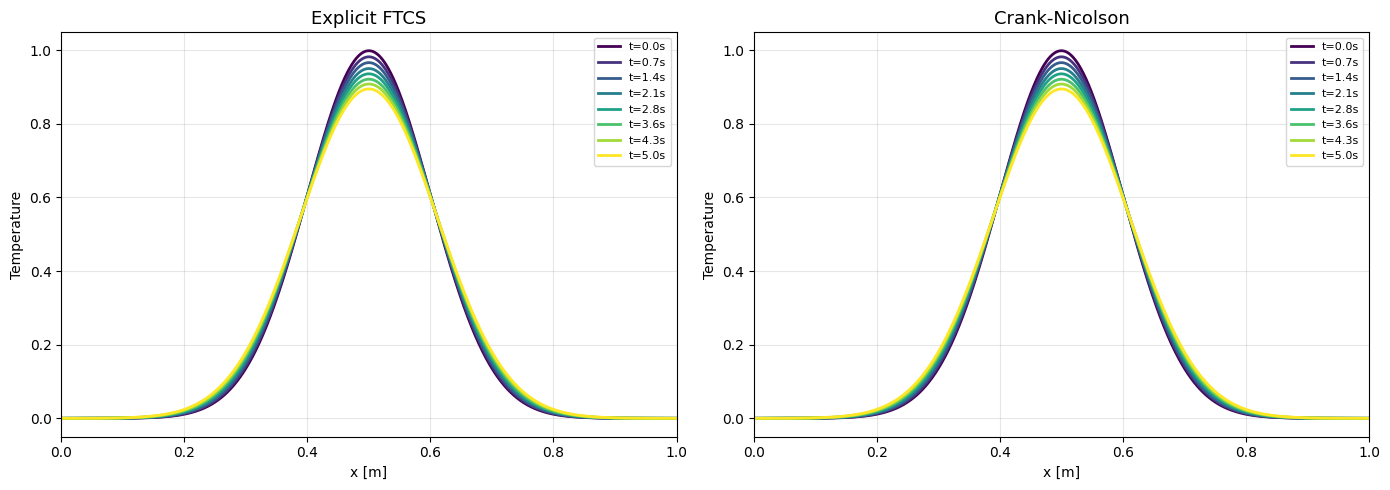

In [6]:
# Collect snapshots using lax.scan that saves every save_every steps
save_every = max(1, nt // 100)
n_saved    = nt // save_every

@jax.jit
def explicit_history(D, u0):
    def step(u, _):
        for _ in range(save_every):
            u = D @ u
        return u, u
    _, history = jax.lax.scan(step, u0, None, length=n_saved)
    return history

@jax.jit
def cn_history(A, B, u0):
    def step(u, _):
        for _ in range(save_every):
            u = jnp.linalg.solve(A, B @ u)
        return u, u
    _, history = jax.lax.scan(step, u0, None, length=n_saved)
    return history

u_exp_hist = np.array(explicit_history(D, u0))
u_cn_hist  = np.array(cn_history(A, B, u0))
x_np       = np.array(x)
t_saved    = np.linspace(0, T_total, n_saved)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
snap_idx  = [int(i * (n_saved - 1) / 7) for i in range(8)]
colors    = plt.cm.viridis(np.linspace(0, 1, 8))

for ax, hist, title in zip(axes,
                            [u_exp_hist, u_cn_hist],
                            ['Explicit FTCS', 'Crank-Nicolson']):
    for idx, c in zip(snap_idx, colors):
        ax.plot(x_np, hist[idx], color=c, lw=2, label=f't={t_saved[idx]:.1f}s')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('Temperature')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, L])

plt.tight_layout()
plt.savefig('jax_evolution.png', dpi=150)
plt.show()

## lax.scan vs torch.compile — Why scan works here

In the PyTorch notebook we saw that `torch.compile(full_loop)` was **slower** than uncompiled
because dynamo unrolled `range(2773)` into a static graph of 2773 nodes.

`jax.lax.scan` solves this differently:
- It compiles the loop body **once** into a single XLA op
- XLA drives it with a native `while` loop — no Python overhead, no graph unrolling
- Works correctly even for large `nt` because the graph size is constant

This is why JAX is especially well-suited for iterative PDE solvers.